# ⚽ K-Means Clustering — Gaya Bermain Klub La Liga

---

## Bagian 0 — Tujuan dan Konsep

### Tujuan

Notebook ini mengelompokkan 20 klub La Liga berdasarkan **kemiripan karakteristik statistik** menggunakan algoritma **K-Means Clustering**. Tujuannya adalah menemukan kelompok-kelompok klub yang memiliki pola statistik serupa, yang kemudian dapat diasosiasikan dengan kecenderungan gaya bermain tertentu.

### Mengapa K-Means?

K-Means dipilih karena:
- Sederhana dan mudah diinterpretasikan.
- Cocok untuk data numerik berdimensi menengah.
- Menghasilkan *hard assignment* — setiap klub masuk tepat satu cluster.
- Menjadi baseline clustering yang umum digunakan dalam riset.

### Konsep Dasar

| Istilah | Penjelasan |
|---------|------------|
| **Observation** | Satu baris data = satu klub La Liga |
| **Feature** | Satu kolom numerik = satu statistik (misal: goals, xG, passes) |
| **Centroid** | Titik pusat sebuah cluster, merepresentasikan "rata-rata" anggota cluster |
| **Cluster** | Kelompok observation yang memiliki kemiripan statistik |
| **Distance** | Jarak antar observation — K-Means menggunakan **Euclidean distance** |

### Unsupervised Learning

Clustering termasuk **unsupervised learning** — tidak ada label "gaya bermain" yang sudah ditentukan sebelumnya. Model menemukan pola pengelompokan secara mandiri berdasarkan kemiripan statistik antar klub. Interpretasi gaya bermain dilakukan **setelah** cluster terbentuk, bukan sebelumnya.

---

## Bagian 1 — Import Library

In [131]:
# Data manipulation
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning — preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning — clustering
from sklearn.cluster import KMeans

# Machine Learning — evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Machine Learning — dimensionality reduction (untuk visualisasi saja)
from sklearn.decomposition import PCA

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42

print("✅ Library berhasil diimpor.")

✅ Library berhasil diimpor.


---

## Bagian 2 — Membaca Data CSV

Dataset `teams_ml_features.csv` merupakan hasil dari proses ETL (Bronze → Silver → Gold) yang telah dilakukan sebelumnya. Dataset ini berisi statistik pertandingan 20 klub La Liga dalam satu musim.

In [ ]:
PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / "data" / "gold" / "teams" / "teams_ml_features.csv"

df = pd.read_csv(data_path)

print(f"✅ Dataset dimuat dari: {data_path.name}")
print(f"   Jumlah baris : {df.shape[0]}")
print(f"   Jumlah kolom : {df.shape[1]}")

✅ Dataset dimuat dari: teams_ml_features.csv
   Jumlah baris : 20
   Jumlah kolom : 53


In [133]:
# --- 5 baris pertama ---
df.head()

,club,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_sp_goals,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_touches_in_box,att_fast_breaks_total,att_fast_breaks_goals,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_avg_possession_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_shots_in_box_pct,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_pct,pas_direction_fwd_pct,pas_through_balls,prs_ppda,prs_pressed_seqs,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_direct_attacks_total,seq_direct_attacks_goals,msc_fouls,msc_yellows,msc_reds,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_pens_conceded
0,Alaves,44,47.05,-3.05,463,153,9.50,0.10,37,41.54,-4.54,11,11.00,25.00,29.16,778,29,1,691,297,1859,148,901,48.00,56,47.67,8.33,473,64.69,15362,12346,80.40,67.70,34.80,32,11.50,416,233,44,4,18.88,1.81,3.14,8.01,56,47,1,539,86,5,19,4,5
1,Athletic Bilbao,43,50.60,-7.60,522,172,8.24,0.10,38,45.87,-7.87,6,10.55,13.95,26.63,978,18,4,571,349,1983,78,808,48.60,58,42.24,15.76,357,64.43,15562,12496,80.30,66.90,35.00,59,11.20,557,368,61,3,16.58,2.03,3.08,8.12,57,42,5,497,73,7,27,6,6
2,Atlético Madrid,62,58.87,3.13,498,193,12.45,0.12,59,55.71,3.29,12,11.00,19.35,26.51,1060,33,8,647,297,1839,114,812,53.30,44,48.98,-4.98,441,61.45,19208,16443,85.60,75.80,30.20,100,12.20,427,267,31,5,11.61,1.70,4.16,11.03,124,64,2,399,77,5,22,4,6
3,Barcelona,95,86.62,8.38,692,257,13.73,0.13,88,78.73,9.27,15,11.48,15.79,22.40,1340,37,11,618,280,1756,95,716,68.80,36,45.33,-9.33,346,77.75,24800,22316,90.00,81.60,25.70,121,8.70,471,294,51,10,17.35,1.68,5.19,14.22,231,65,9,348,59,2,22,3,5
4,Celta Vigo,53,49.52,3.48,382,153,13.87,0.13,45,43.21,1.79,7,6.27,13.21,20.42,749,25,3,545,274,1710,130,914,50.50,48,49.70,-1.70,478,64.44,18909,16281,86.10,74.90,29.00,121,13.90,350,214,33,5,15.42,1.60,4.38,11.65,110,53,4,425,71,1,34,8,11


In [134]:
# --- 5 baris terakhir ---
df.tail()

,club,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_sp_goals,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_touches_in_box,att_fast_breaks_total,att_fast_breaks_goals,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_avg_possession_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_shots_in_box_pct,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_pct,pas_direction_fwd_pct,pas_through_balls,prs_ppda,prs_pressed_seqs,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_direct_attacks_total,seq_direct_attacks_goals,msc_fouls,msc_yellows,msc_reds,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_pens_conceded
15,Real Oviedo,26,35.84,-9.84,376,119,6.91,0.10,24,33.48,-9.48,10,9.57,38.46,29.52,637,22,3,678,301,1721,158,1021,46.10,60,60.05,-0.05,567,62.61,14851,12147,81.80,67.70,34.10,36,12.80,293,211,34,2,16.11,1.72,3.26,9.25,42,37,2,449,73,10,40,13,7
16,Real Sociedad,59,54.42,4.58,469,175,12.58,0.12,51,47.33,3.67,9,12.04,15.25,31.56,820,32,7,678,299,1737,145,947,51.30,61,57.72,3.28,529,63.71,17033,14161,83.10,69.90,34.40,79,10.40,429,256,48,4,18.75,1.91,3.56,9.48,49,46,4,519,88,4,27,7,5
17,Sevilla,46,39.28,6.72,437,137,10.53,0.09,41,34.55,6.45,5,6.59,10.87,27.69,812,36,6,687,326,1803,116,924,51.00,60,57.23,2.77,402,70.15,15396,12521,81.30,68.40,34.20,40,10.60,390,248,39,4,15.73,1.89,3.29,8.86,50,53,3,531,105,5,35,7,11
18,Valencia,46,49.19,-3.19,449,123,10.24,0.11,41,42.10,-1.10,10,9.58,21.74,28.73,812,32,6,605,292,1780,116,1010,47.60,55,47.51,7.49,446,65.70,15423,12603,81.70,68.50,33.10,50,13.50,398,252,40,4,15.87,1.83,3.29,9.18,62,48,6,440,71,3,23,7,8
19,Villarreal,72,59.04,12.96,455,172,15.82,0.13,65,53.52,11.48,7,7.81,9.72,22.64,945,57,14,655,331,1784,158,1026,44.50,46,46.15,-0.15,486,60.91,15550,12927,83.10,71.20,31.60,80,15.10,367,218,23,3,10.55,1.99,3.48,9.28,75,90,12,427,77,3,42,13,8


In [135]:
# --- Nama seluruh kolom ---
print(f"Seluruh kolom ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:>2d}. {col}")

Seluruh kolom (53):
    1. club
    2. att_goals
    3. att_xg
    4. att_goals_vs_xg
    5. att_shots
    6. att_sot
    7. att_conversion_pct
    8. att_xg_per_shot
    9. att_np_goals
   10. att_np_xg
   11. att_np_goals_vs_xg
   12. att_sp_goals
   13. att_sp_xg
   14. att_sp_goal_pct
   15. att_sp_shot_pct
   16. att_touches_in_box
   17. att_fast_breaks_total
   18. att_fast_breaks_goals
   19. def_tackles
   20. def_interceptions
   21. def_possession_won
   22. def_blocks
   23. def_clearances
   24. def_avg_possession_pct
   25. def_goals_conceded
   26. def_xg_against
   27. def_goals_vs_xg_against
   28. def_shots_against
   29. def_shots_in_box_pct
   30. pas_passes_total
   31. pas_passes_successful
   32. pas_passes_pct
   33. pas_final_third_pct
   34. pas_direction_fwd_pct
   35. pas_through_balls
   36. prs_ppda
   37. prs_pressed_seqs
   38. prs_high_turnovers_total
   39. prs_high_turnovers_shot_ending
   40. prs_high_turnovers_goal_ending
   41. prs_high_turnovers_s

In [136]:
# --- Tipe data ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   club                            20 non-null     str    
 1   att_goals                       20 non-null     int64  
 2   att_xg                          20 non-null     float64
 3   att_goals_vs_xg                 20 non-null     float64
 4   att_shots                       20 non-null     int64  
 5   att_sot                         20 non-null     int64  
 6   att_conversion_pct              20 non-null     float64
 7   att_xg_per_shot                 20 non-null     float64
 8   att_np_goals                    20 non-null     int64  
 9   att_np_xg                       20 non-null     float64
 10  att_np_goals_vs_xg              20 non-null     float64
 11  att_sp_goals                    20 non-null     int64  
 12  att_sp_xg                       20 non-null     f

### Interpretasi

- **Observation**: Setiap baris merepresentasikan satu klub La Liga.
- **Feature**: Terdapat 52 feature numerik yang mencakup aspek attacking, defending, passing, pressing, sequences, dan discipline.
- **Identifier**: Kolom `club` merupakan identifier (nama klub) dan bukan feature numerik.
- Kolom non-numerik hanya `club` — sisanya adalah feature yang siap digunakan untuk clustering.

---

## Bagian 3 — Data Validation / Data Quality Check

Sebelum masuk ke Machine Learning, penting untuk memvalidasi bahwa dataset benar-benar bersih dan siap digunakan.

In [137]:
# --- Identifikasi kolom numerik ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Kolom numerik     : {len(numeric_cols)}")
print(f"Kolom non-numerik : {len(non_numeric_cols)} → {non_numeric_cols}")

Kolom numerik     : 52
Kolom non-numerik : 1 → ['club']


In [138]:
# === 1. Missing Values ===
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_total = missing.sum()

print(f"1️⃣  Missing Values: {missing_total}")
if missing_total > 0:
    print(missing_df[missing_df["missing_count"] > 0])
else:
    print("   ✅ Tidak ada missing values.")

1️⃣  Missing Values: 0
   ✅ Tidak ada missing values.


In [139]:
# === 2. Duplicate Rows ===
dup_rows = df.duplicated().sum()
print(f"2️⃣  Duplicate rows: {dup_rows}")
if dup_rows == 0:
    print("   ✅ Tidak ada baris duplikat.")

# === 3. Duplicate Club ===
dup_clubs = df["club"].duplicated().sum()
print(f"\n3️⃣  Duplicate club: {dup_clubs}")
if dup_clubs == 0:
    print("   ✅ Setiap klub unik.")

2️⃣  Duplicate rows: 0
   ✅ Tidak ada baris duplikat.

3️⃣  Duplicate club: 0
   ✅ Setiap klub unik.


In [140]:
# === 4. Data Types ===
print("4️⃣  Tipe data:")
print(df.dtypes.value_counts().to_string())
print("   ✅ Seluruh feature bertipe numerik.")

4️⃣  Tipe data:
int64      31
float64    21
str         1
   ✅ Seluruh feature bertipe numerik.


In [141]:
# === 5. Infinite Values ===
inf_count = np.isinf(df[numeric_cols]).sum().sum()
print(f"5️⃣  Infinite values: {inf_count}")
if inf_count == 0:
    print("   ✅ Tidak ada nilai infinite.")

# === 6. Nilai Numerik Tidak Valid (NaN setelah konversi) ===
invalid = df[numeric_cols].apply(lambda col: pd.to_numeric(col, errors='coerce')).isnull().sum().sum()
print(f"\n6️⃣  Nilai numerik tidak valid: {invalid}")
if invalid == 0:
    print("   ✅ Seluruh nilai numerik valid.")

5️⃣  Infinite values: 0
   ✅ Tidak ada nilai infinite.

6️⃣  Nilai numerik tidak valid: 0
   ✅ Seluruh nilai numerik valid.


In [142]:
# === 7. Jumlah Unique Value ===
print("7️⃣  Unique values per kolom:\n")
unique_counts = df.nunique()
for col in df.columns:
    print(f"   {col:<45s}  {unique_counts[col]:>3d} unique")

7️⃣  Unique values per kolom:

   club                                            20 unique
   att_goals                                       15 unique
   att_xg                                          20 unique
   att_goals_vs_xg                                 20 unique
   att_shots                                       20 unique
   att_sot                                         16 unique
   att_conversion_pct                              20 unique
   att_xg_per_shot                                  5 unique
   att_np_goals                                    14 unique
   att_np_xg                                       20 unique
   att_np_goals_vs_xg                              20 unique
   att_sp_goals                                    12 unique
   att_sp_xg                                       18 unique
   att_sp_goal_pct                                 19 unique
   att_sp_shot_pct                                 20 unique
   att_touches_in_box                              19 

In [143]:
# === 8. Statistik Deskriptif ===
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
att_goals,20.00,51.20,15.97,26.00,43.00,46.50,59.00,95.00
att_xg,20.00,51.49,12.84,30.59,45.34,49.36,54.72,86.62
att_goals_vs_xg,20.00,-0.29,6.77,-12.19,-5.80,0.20,3.77,12.96
att_shots,20.00,474.30,86.12,352.00,422.00,459.00,504.00,692.00
att_sot,20.00,164.80,38.08,105.00,146.50,157.50,177.25,257.00
att_conversion_pct,20.00,10.71,2.24,6.91,9.16,10.38,12.07,15.82
att_xg_per_shot,20.00,0.11,0.01,0.09,0.10,0.10,0.12,0.13
att_np_goals,20.00,46.00,14.68,24.00,38.00,41.50,52.25,88.00
att_np_xg,20.00,46.21,11.66,27.43,39.39,44.11,50.26,78.73
att_np_goals_vs_xg,20.00,-0.21,6.47,-11.25,-4.66,0.34,3.76,11.48


### Interpretasi

Dataset telah **lolos seluruh validation**:
- Tidak ada missing values, duplicate, infinite values, atau tipe data yang salah.
- Setiap klub unik (20 observation).
- Seluruh 52 feature bertipe numerik.
- Dataset siap digunakan untuk Machine Learning tanpa perlu cleaning tambahan.

---

## Bagian 4 — Memahami 53 Kolom

K-Means membutuhkan **representasi numerik** karena perhitungan clustering menggunakan jarak (Euclidean distance). Oleh karena itu, perlu dipisahkan antara kolom **identifier** dan kolom **feature numerik**.

In [144]:
# --- Klasifikasi kolom ---
identifier_cols = ["club"]
feature_cols = [c for c in df.columns if c not in identifier_cols]

print("A. Identifier:")
for col in identifier_cols:
    print(f"   • {col} (tipe: {df[col].dtype})")

print(f"\nB. Numerical Features: {len(feature_cols)} kolom")
print()

# Ringkasan statistik feature
feature_stats = df[feature_cols].agg(["min", "max", "mean", "std"]).T
feature_stats.columns = ["Min", "Max", "Mean", "Std"]
feature_stats

A. Identifier:
   • club (tipe: str)

B. Numerical Features: 52 kolom



,Min,Max,Mean,Std
att_goals,26.00,95.00,51.20,15.97
att_xg,30.59,86.62,51.49,12.84
att_goals_vs_xg,-12.19,12.96,-0.29,6.77
att_shots,352.00,692.00,474.30,86.12
att_sot,105.00,257.00,164.80,38.08
att_conversion_pct,6.91,15.82,10.71,2.24
att_xg_per_shot,0.09,0.13,0.11,0.01
att_np_goals,24.00,88.00,46.00,14.68
att_np_xg,27.43,78.73,46.21,11.66
att_np_goals_vs_xg,-11.25,11.48,-0.21,6.47


### Interpretasi

Dari 53 kolom:
- **1 kolom** adalah identifier (`club`) → tidak digunakan sebagai input K-Means.
- **52 kolom** adalah feature numerik → digunakan sebagai input K-Means.

Feature mencakup kategori: attacking, defending, passing, pressing, sequences, dan discipline. Seluruh feature merepresentasikan statistik pertandingan selama satu musim penuh.

---

## Bagian 5 — Menentukan Input untuk K-Means

Matriks input `X` hanya berisi **feature numerik**. Kolom identifier (`club`) dan kolom hasil clustering sebelumnya (jika ada) **tidak boleh** menjadi input model.

In [145]:
# --- Kolom yang TIDAK boleh menjadi input ---
exclude_patterns = ["club", "cluster", "probability", "prob_"]
input_cols = [c for c in df.columns
              if not any(p in c.lower() for p in exclude_patterns)
              and df[c].dtype in [np.float64, np.int64, float, int]]

X = df[input_cols].copy()
clubs = df["club"].copy()

print(f"✅ Matriks input X:")
print(f"   Observations (klub) : {X.shape[0]}")
print(f"   Features            : {X.shape[1]}")
print(f"\n   Kolom yang dikeluarkan: {[c for c in df.columns if c not in input_cols]}")

✅ Matriks input X:
   Observations (klub) : 20
   Features            : 52

   Kolom yang dikeluarkan: ['club']


---

## Bagian 6 — Eksplorasi Skala Feature

### Mengapa Scaling Diperlukan?

K-Means menggunakan **Euclidean distance** untuk mengukur kemiripan antar observation:

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

Jika feature memiliki skala yang sangat berbeda, feature berskala besar akan **mendominasi** perhitungan jarak. Misalnya, `pas_passes_total` (ribuan) akan jauh lebih berpengaruh dibandingkan `att_conversion_pct` (satuan persen).

Scaling memastikan setiap feature berkontribusi **secara proporsional** terhadap distance.

In [146]:
# --- Contoh perbedaan skala ---
example_features = ["pas_passes_total", "att_goals", "att_conversion_pct",
                    "prs_ppda", "def_clearances", "att_xg_per_shot"]
example_features = [f for f in example_features if f in X.columns]

print("📊 Contoh perbedaan skala feature:\n")
for feat in example_features:
    print(f"   {feat:<30s}  min={X[feat].min():>10.2f}   max={X[feat].max():>10.2f}")

print(f"\n⚠️  Rentang 'pas_passes_total' ({X['pas_passes_total'].min():.0f}–{X['pas_passes_total'].max():.0f}) "
      f"sangat berbeda dengan 'att_xg_per_shot' ({X['att_xg_per_shot'].min():.2f}–{X['att_xg_per_shot'].max():.2f}).")
print("   Tanpa scaling, passes akan mendominasi perhitungan jarak K-Means.")

📊 Contoh perbedaan skala feature:

   pas_passes_total                min=  10912.00   max=  24800.00
   att_goals                       min=     26.00   max=     95.00
   att_conversion_pct              min=      6.91   max=     15.82
   prs_ppda                        min=      8.70   max=     15.10
   def_clearances                  min=    639.00   max=   1099.00
   att_xg_per_shot                 min=      0.09   max=      0.13

⚠️  Rentang 'pas_passes_total' (10912–24800) sangat berbeda dengan 'att_xg_per_shot' (0.09–0.13).
   Tanpa scaling, passes akan mendominasi perhitungan jarak K-Means.


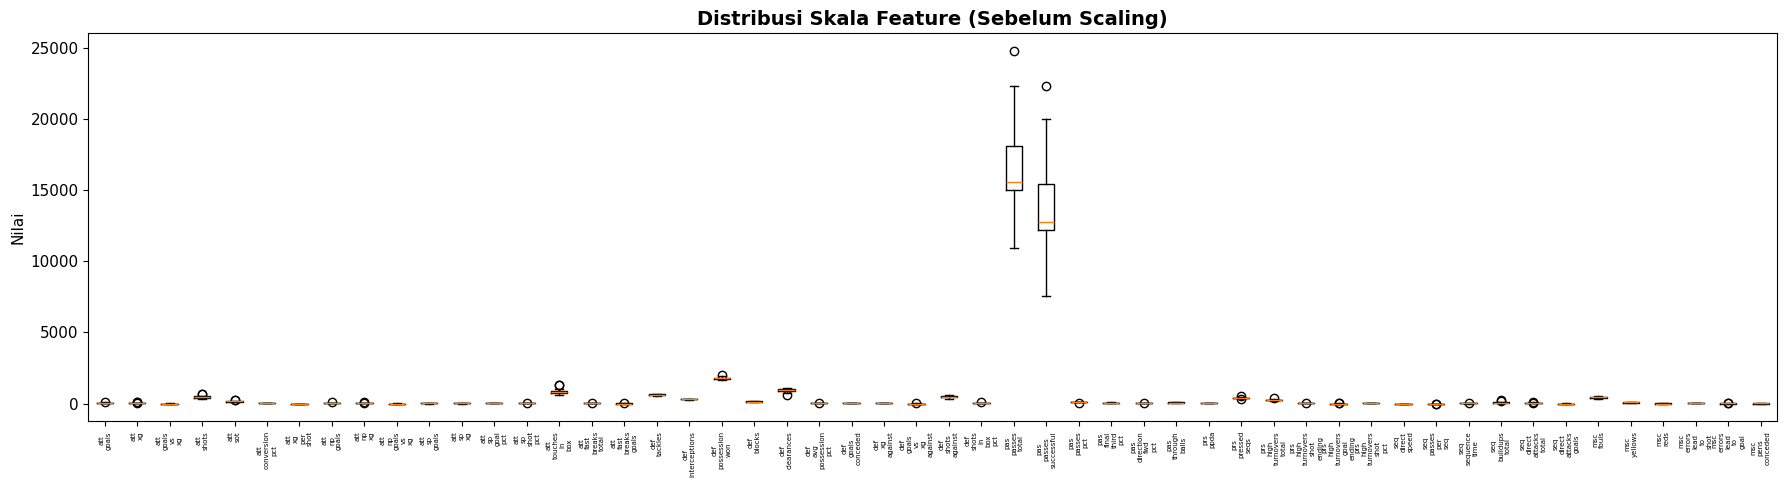

In [147]:
# --- Visualisasi distribusi skala (boxplot) ---
fig, ax = plt.subplots(figsize=(18, 5))
ax.boxplot(X.values, vert=True,
           labels=[c.replace("_", "\n") for c in X.columns])
ax.set_title("Distribusi Skala Feature (Sebelum Scaling)", fontsize=14, fontweight="bold")
ax.set_ylabel("Nilai")
plt.xticks(fontsize=5, rotation=90)
plt.tight_layout()
plt.show()

### Interpretasi

Grafik di atas menunjukkan bahwa skala antar feature sangat beragam. Feature seperti total passes dan total passes successful memiliki nilai ribuan, sementara rasio dan persentase berada di bawah 100. **Scaling wajib dilakukan** sebelum K-Means agar seluruh feature memiliki kontribusi yang seimbang.

---

## Bagian 7 — Feature Scaling

Digunakan **StandardScaler** yang mentransformasi setiap feature agar memiliki:
- Mean ≈ 0
- Standard deviation ≈ 1

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

Scaling **tidak mengubah** urutan atau relasi dasar antar data. Klub dengan goals tinggi tetap memiliki nilai yang lebih tinggi dibanding klub dengan goals rendah — hanya skalanya yang diseragamkan.

In [148]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=input_cols, index=X.index)

print("📊 Setelah StandardScaler:")
print(f"   Shape: {X_scaled.shape}")
print(f"\n   Contoh mean dan std (5 feature pertama):")
for feat in input_cols[:5]:
    col_idx = input_cols.index(feat)
    print(f"   {feat:<35s}  mean = {X_scaled[:, col_idx].mean():>7.4f}   std = {X_scaled[:, col_idx].std():>6.4f}")
print(f"\n   ✅ Seluruh feature: mean ≈ 0, std ≈ 1")

📊 Setelah StandardScaler:
   Shape: (20, 52)

   Contoh mean dan std (5 feature pertama):
   att_goals                            mean = -0.0000   std = 1.0000
   att_xg                               mean = -0.0000   std = 1.0000
   att_goals_vs_xg                      mean =  0.0000   std = 1.0000
   att_shots                            mean = -0.0000   std = 1.0000
   att_sot                              mean = -0.0000   std = 1.0000

   ✅ Seluruh feature: mean ≈ 0, std ≈ 1


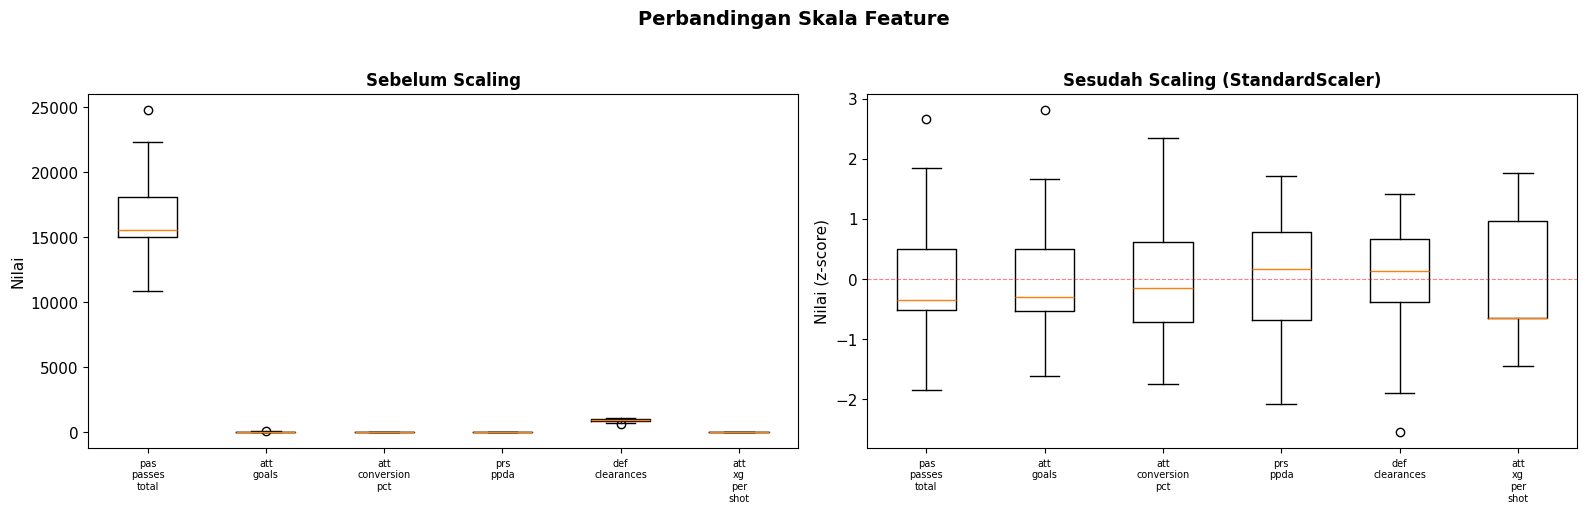

In [149]:
# --- Visualisasi sebelum vs sesudah scaling ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].boxplot(X[example_features].values, vert=True,
                labels=[f.replace("_", "\n") for f in example_features])
axes[0].set_title("Sebelum Scaling", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nilai")
axes[0].tick_params(axis='x', labelsize=7)

scaled_examples = X_scaled_df[example_features].values
axes[1].boxplot(scaled_examples, vert=True,
                labels=[f.replace("_", "\n") for f in example_features])
axes[1].set_title("Sesudah Scaling (StandardScaler)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nilai (z-score)")
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].tick_params(axis='x', labelsize=7)

plt.suptitle("Perbandingan Skala Feature", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Interpretasi

Setelah scaling, seluruh feature berada dalam skala yang sebanding. Feature yang sebelumnya memiliki nilai ribuan (passes) dan feature yang sebelumnya memiliki nilai desimal (xG per shot) sekarang berada dalam rentang yang serupa. K-Means kini dapat menghitung jarak secara adil.

---

## Bagian 8 — Menentukan Jumlah Cluster (K)

Jumlah cluster **tidak** ditentukan secara sembarang. Digunakan dua metrik:

### Elbow Method (Inertia)
- **Inertia** = total jarak kuadrat dari setiap observation ke centroid cluster-nya.
- Semakin kecil inertia, semakin compact cluster.
- Inertia **selalu turun** saat K bertambah, sehingga dicari titik *"elbow"* — titik di mana penurunan mulai melambat.

### Silhouette Score
- Mengukur seberapa baik setiap observation berada dalam cluster-nya dibandingkan cluster terdekat lainnya.
- Rentang: -1 (buruk) hingga +1 (sempurna).
- **Semakin mendekati 1, semakin baik.**

In [150]:
K_CANDIDATES = range(2, 9)  # K = 2 sampai 8

inertias = []
silhouettes = []

for k in K_CANDIDATES:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Tabel hasil
eval_df = pd.DataFrame({
    "K": list(K_CANDIDATES),
    "Inertia": inertias,
    "Silhouette": silhouettes,
})

print("📊 Evaluasi Jumlah Cluster:\n")
print(eval_df.to_string(index=False))

📊 Evaluasi Jumlah Cluster:

 K  Inertia  Silhouette
 2   739.34        0.39
 3   595.63        0.15
 4   531.48        0.11
 5   459.09        0.13
 6   386.41        0.13
 7   340.74        0.10
 8   290.29        0.11


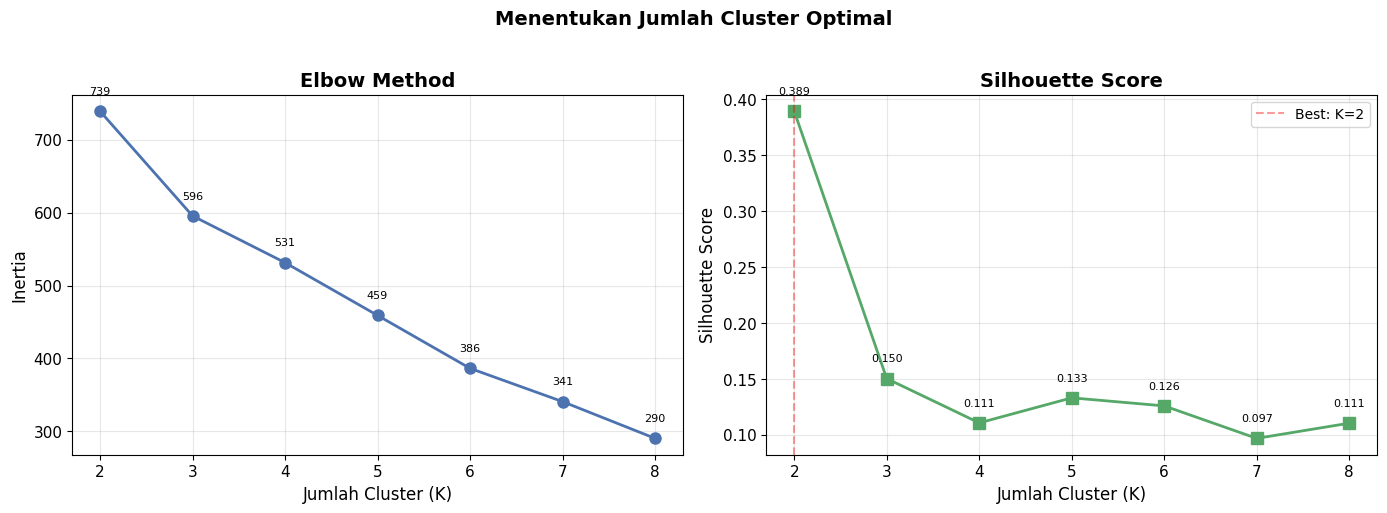

In [151]:
# --- Visualisasi: Elbow + Silhouette ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_CANDIDATES, inertias, marker='o', linewidth=2, markersize=8, color='#4C72B0')
axes[0].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(K_CANDIDATES))
axes[0].grid(True, alpha=0.3)
for k, ine in zip(K_CANDIDATES, inertias):
    axes[0].annotate(f"{ine:.0f}", (k, ine), textcoords="offset points",
                     xytext=(0, 12), fontsize=8, ha='center')

# Silhouette
axes[1].plot(K_CANDIDATES, silhouettes, marker='s', linewidth=2, markersize=8, color='#55A868')
axes[1].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(K_CANDIDATES))
axes[1].grid(True, alpha=0.3)
for k, sil in zip(K_CANDIDATES, silhouettes):
    axes[1].annotate(f"{sil:.3f}", (k, sil), textcoords="offset points",
                     xytext=(0, 12), fontsize=8, ha='center')

# Highlight best silhouette
best_k_sil = list(K_CANDIDATES)[np.argmax(silhouettes)]
axes[1].axvline(best_k_sil, color='red', linestyle='--', alpha=0.4,
                label=f'Best: K={best_k_sil}')
axes[1].legend(fontsize=10)

plt.suptitle('Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [152]:
# ============================================================
# KEPUTUSAN: Pilih K
# ============================================================
# Pertimbangan:
# - Elbow: penurunan inertia yang melambat
# - Silhouette: skor tertinggi
# - Interpretabilitas: jumlah cluster yang masuk akal untuk analisis sepakbola

OPTIMAL_K = 3  # Sesuaikan jika elbow menunjukkan K lain

print(f"📊 Rekomendasi:")
print(f"   Silhouette tertinggi : K = {best_k_sil} (score = {max(silhouettes):.4f})")
print(f"\n✅ K yang dipilih: {OPTIMAL_K}")

📊 Rekomendasi:
   Silhouette tertinggi : K = 2 (score = 0.3893)

✅ K yang dipilih: 3


### Interpretasi

Pemilihan K mempertimbangkan:
1. **Elbow** — mencari titik penurunan inertia yang mulai melambat.
2. **Silhouette** — memilih K dengan skor tertinggi (separasi terbaik).
3. **Interpretabilitas** — jumlah cluster harus cukup untuk membedakan gaya bermain, tetapi tidak terlalu banyak sehingga sulit diinterpretasikan (20 klub dibagi ke lebih dari 6–7 cluster kurang bermakna).

---

## Bagian 9 — Training Final K-Means

In [153]:
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=50,
)

cluster_labels = kmeans.fit_predict(X_scaled)

# --- Hasil clustering ---
cluster_results = pd.DataFrame({
    "club": clubs.values,
    "cluster": cluster_labels,
})
cluster_results = cluster_results.sort_values(["cluster", "club"]).reset_index(drop=True)

print(f"✅ K-Means training selesai.")
print(f"   K               : {OPTIMAL_K}")
print(f"   Inertia         : {kmeans.inertia_:.2f}")
print(f"   Silhouette      : {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"   Iterations      : {kmeans.n_iter_}")
print(f"\n📋 Hasil:")
cluster_results

✅ K-Means training selesai.
   K               : 3
   Inertia         : 595.63
   Silhouette      : 0.1504
   Iterations      : 3

📋 Hasil:


,club,cluster
0,Atlético Madrid,0
1,Celta Vigo,0
2,Elche,0
3,Girona,0
4,Mallorca,0
5,Real Betis,0
6,Real Sociedad,0
7,Sevilla,0
8,Villarreal,0
9,Alaves,1


---

## Bagian 10 — Memahami Centroid

**Centroid** adalah titik pusat setiap cluster — merepresentasikan "rata-rata" karakteristik statistik anggota cluster. Karena model dilatih pada data yang telah di-scale, centroid awalnya berada dalam *standardized space*. Untuk memudahkan interpretasi, centroid di-*inverse transform* ke skala asli.

In [154]:
# --- Centroid dalam standardized space ---
centroids_scaled = kmeans.cluster_centers_
print(f"Centroid (standardized): {centroids_scaled.shape}")

# --- Inverse transform ke skala asli ---
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=input_cols)
centroids_df.index.name = "cluster"

print(f"\n📊 Centroid dalam skala asli:\n")
centroids_df.round(2)

Centroid (standardized): (3, 52)

📊 Centroid dalam skala asli:



,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_sp_goals,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_touches_in_box,att_fast_breaks_total,att_fast_breaks_goals,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_avg_possession_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_shots_in_box_pct,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_pct,pas_direction_fwd_pct,pas_through_balls,prs_ppda,prs_pressed_seqs,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_direct_attacks_total,seq_direct_attacks_goals,msc_fouls,msc_yellows,msc_reds,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_pens_conceded
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,54.00,50.12,3.88,447.78,163.78,12.07,0.11,48.44,45.12,3.32,7.78,8.41,14.48,24.94,838.22,36.89,6.44,632.33,304.78,1776.33,137.67,956.33,50.68,52.89,54.26,-1.37,491.56,64.32,17306.11,14577.11,84.08,72.60,32.19,67.56,12.61,382.67,239.44,37.00,3.89,15.34,1.81,3.75,10.21,80.44,59.89,4.89,442.56,80.22,4.33,29.00,7.44,7.67
1,40.67,46.01,-5.35,455.44,145.78,8.92,0.10,36.78,41.37,-4.59,11.22,11.07,28.27,31.82,771.33,29.67,3.44,630.44,315.56,1799.33,132.33,971.89,46.19,53.00,50.55,2.45,478.56,64.11,14375.78,11452.33,79.30,64.69,36.19,41.44,12.27,423.78,253.56,40.56,2.67,16.01,1.91,3.03,8.13,44.44,46.00,2.89,484.11,84.78,6.56,23.00,6.11,6.22
2,86.00,82.31,3.69,678.50,255.00,12.66,0.12,76.50,72.84,3.66,14.00,13.12,16.34,24.36,1336.50,41.50,9.50,604.50,266.00,1766.00,109.50,677.50,64.10,35.50,43.25,-7.75,377.50,70.30,23553.50,21159.00,89.85,81.80,26.70,109.00,10.10,443.00,286.50,58.00,10.50,20.33,1.71,5.05,13.89,200.00,84.00,8.00,353.50,63.50,4.50,24.50,4.00,4.50


In [155]:
# --- Perbandingan centroid: fitur kunci ---
key_features = ["att_goals", "att_xg", "att_shots", "def_avg_possession_pct",
                "pas_passes_pct", "prs_ppda", "def_goals_conceded",
                "seq_buildups_total", "msc_fouls", "att_fast_breaks_total"]
key_features = [f for f in key_features if f in input_cols]

print("📊 Perbandingan Centroid — Feature Kunci:\n")
comparison = centroids_df[key_features].T
comparison.columns = [f"Cluster {i}" for i in range(OPTIMAL_K)]
comparison["Liga Mean"] = X[key_features].mean().values
comparison.round(2)

📊 Perbandingan Centroid — Feature Kunci:



,Cluster 0,Cluster 1,Cluster 2,Liga Mean
att_goals,54.00,40.67,86.00,51.20
att_xg,50.12,46.01,82.31,51.49
att_shots,447.78,455.44,678.50,474.30
def_avg_possession_pct,50.68,46.19,64.10,50.00
pas_passes_pct,84.08,79.30,89.85,82.50
prs_ppda,12.61,12.27,10.10,12.20
def_goals_conceded,52.89,53.00,35.50,51.20
seq_buildups_total,80.44,44.44,200.00,76.20
msc_fouls,442.56,484.11,353.50,452.35
att_fast_breaks_total,36.89,29.67,41.50,34.10


### Interpretasi

Tabel di atas membandingkan centroid setiap cluster dengan rata-rata liga. Feature yang nilainya **di atas rata-rata liga** mengindikasikan kekuatan cluster, sedangkan yang **di bawah** mengindikasikan kelemahan relatif.

---

## Bagian 11 — Ukuran / Komposisi Cluster

In [156]:
cluster_sizes = cluster_results["cluster"].value_counts().sort_index()

print("📊 Jumlah Klub per Cluster:\n")
for cid, cnt in cluster_sizes.items():
    print(f"   Cluster {cid}: {cnt} klub")

print(f"\n   Total: {cluster_sizes.sum()} klub")
assert cluster_sizes.min() > 0, "Ada cluster kosong!"
print("   ✅ Tidak ada cluster kosong.")

📊 Jumlah Klub per Cluster:

   Cluster 0: 9 klub
   Cluster 1: 9 klub
   Cluster 2: 2 klub

   Total: 20 klub
   ✅ Tidak ada cluster kosong.


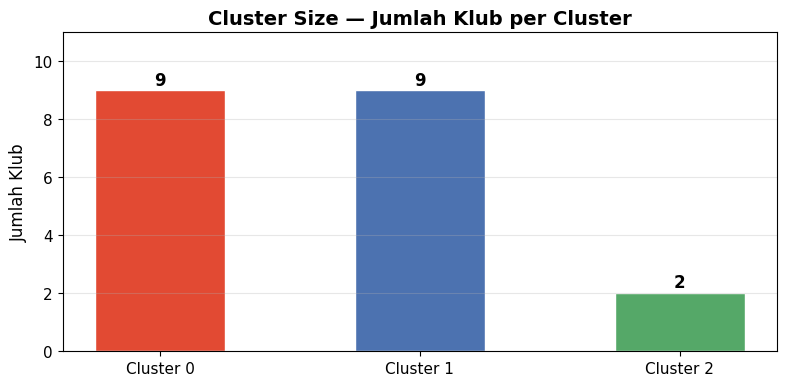

In [157]:
cluster_colors = ['#E24A33', '#4C72B0', '#55A868', '#8172B2', '#C44E52',
                  '#CCB974', '#64B5CD', '#8C8C8C', '#FF9F1C', '#2EC4B6']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f"Cluster {i}" for i in cluster_sizes.index],
    cluster_sizes.values,
    color=[cluster_colors[i] for i in cluster_sizes.index],
    edgecolor='white', width=0.5,
)
for bar, cnt in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(cnt), ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel("Jumlah Klub", fontsize=12)
ax.set_title("Cluster Size — Jumlah Klub per Cluster", fontsize=14, fontweight="bold")
ax.set_ylim(0, cluster_sizes.max() + 2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Interpretasi

Distribusi cluster menunjukkan apakah pengelompokan cukup merata atau terdapat cluster yang sangat dominan. Cluster yang berisi sedikit klub mengindikasikan kelompok dengan karakteristik yang lebih unik.

---

## Bagian 12 — Profil Cluster

Bagian ini mengidentifikasi **"signature"** setiap cluster dengan menghitung rata-rata feature per cluster dan membandingkannya dengan rata-rata seluruh liga.

In [158]:
# --- Gabungkan cluster label ke dataframe ---
df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

# --- Mean per cluster ---
cluster_profile = df_clustered.groupby("cluster")[input_cols].mean()

print("📊 Cluster Profile — Rata-rata Feature per Cluster:\n")
cluster_profile.round(2)

📊 Cluster Profile — Rata-rata Feature per Cluster:



,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_sp_goals,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_touches_in_box,att_fast_breaks_total,att_fast_breaks_goals,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_avg_possession_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_shots_in_box_pct,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_pct,pas_direction_fwd_pct,pas_through_balls,prs_ppda,prs_pressed_seqs,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_direct_attacks_total,seq_direct_attacks_goals,msc_fouls,msc_yellows,msc_reds,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_pens_conceded
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,54.00,50.12,3.88,447.78,163.78,12.07,0.11,48.44,45.12,3.32,7.78,8.41,14.48,24.94,838.22,36.89,6.44,632.33,304.78,1776.33,137.67,956.33,50.68,52.89,54.26,-1.37,491.56,64.32,17306.11,14577.11,84.08,72.60,32.19,67.56,12.61,382.67,239.44,37.00,3.89,15.34,1.81,3.75,10.21,80.44,59.89,4.89,442.56,80.22,4.33,29.00,7.44,7.67
1,40.67,46.01,-5.35,455.44,145.78,8.92,0.10,36.78,41.37,-4.59,11.22,11.07,28.27,31.82,771.33,29.67,3.44,630.44,315.56,1799.33,132.33,971.89,46.19,53.00,50.55,2.45,478.56,64.11,14375.78,11452.33,79.30,64.69,36.19,41.44,12.27,423.78,253.56,40.56,2.67,16.01,1.91,3.03,8.13,44.44,46.00,2.89,484.11,84.78,6.56,23.00,6.11,6.22
2,86.00,82.31,3.69,678.50,255.00,12.66,0.12,76.50,72.84,3.66,14.00,13.12,16.34,24.36,1336.50,41.50,9.50,604.50,266.00,1766.00,109.50,677.50,64.10,35.50,43.25,-7.75,377.50,70.30,23553.50,21159.00,89.85,81.80,26.70,109.00,10.10,443.00,286.50,58.00,10.50,20.33,1.71,5.05,13.89,200.00,84.00,8.00,353.50,63.50,4.50,24.50,4.00,4.50


In [159]:
# --- Z-score cluster vs liga (untuk identifikasi fitur menonjol) ---
global_mean = df[input_cols].mean()
global_std = df[input_cols].std()
cluster_zscore = (cluster_profile - global_mean) / global_std

# Top 8 dan Bottom 8 feature per cluster
print("🔍 Feature yang Paling Membedakan Setiap Cluster:")
print("   (Z-score: selisih dari rata-rata liga dalam satuan std)")
print("=" * 75)

for cid in sorted(cluster_zscore.index):
    zs = cluster_zscore.loc[cid].sort_values(ascending=False)
    clubs_in = cluster_results[cluster_results["cluster"] == cid]["club"].tolist()

    print(f"\n── Cluster {cid} ({len(clubs_in)} klub) ──")

    print(f"   🟢 Relatif TINGGI:")
    for feat, z in zs.head(8).items():
        print(f"      {feat:<40s}  z = {z:+.2f}")

    print(f"   🔴 Relatif RENDAH:")
    for feat, z in zs.tail(8).items():
        print(f"      {feat:<40s}  z = {z:+.2f}")

print("\n" + "=" * 75)

🔍 Feature yang Paling Membedakan Setiap Cluster:
   (Z-score: selisih dari rata-rata liga dalam satuan std)

── Cluster 0 (9 klub) ──
   🟢 Relatif TINGGI:
      att_goals_vs_xg                           z = +0.62
      att_conversion_pct                        z = +0.61
      att_np_goals_vs_xg                        z = +0.55
      msc_pens_conceded                         z = +0.46
      msc_errors_lead_to_shot                   z = +0.42
      def_xg_against                            z = +0.40
      pas_final_third_pct                       z = +0.39
      pas_passes_pct                            z = +0.35
   🔴 Relatif RENDAH:
      prs_high_turnovers_total                  z = -0.31
      prs_high_turnovers_shot_ending            z = -0.32
      msc_reds                                  z = -0.42
      prs_pressed_seqs                          z = -0.43
      att_sp_shot_pct                           z = -0.56
      att_sp_goals                              z = -0.64
      att_sp

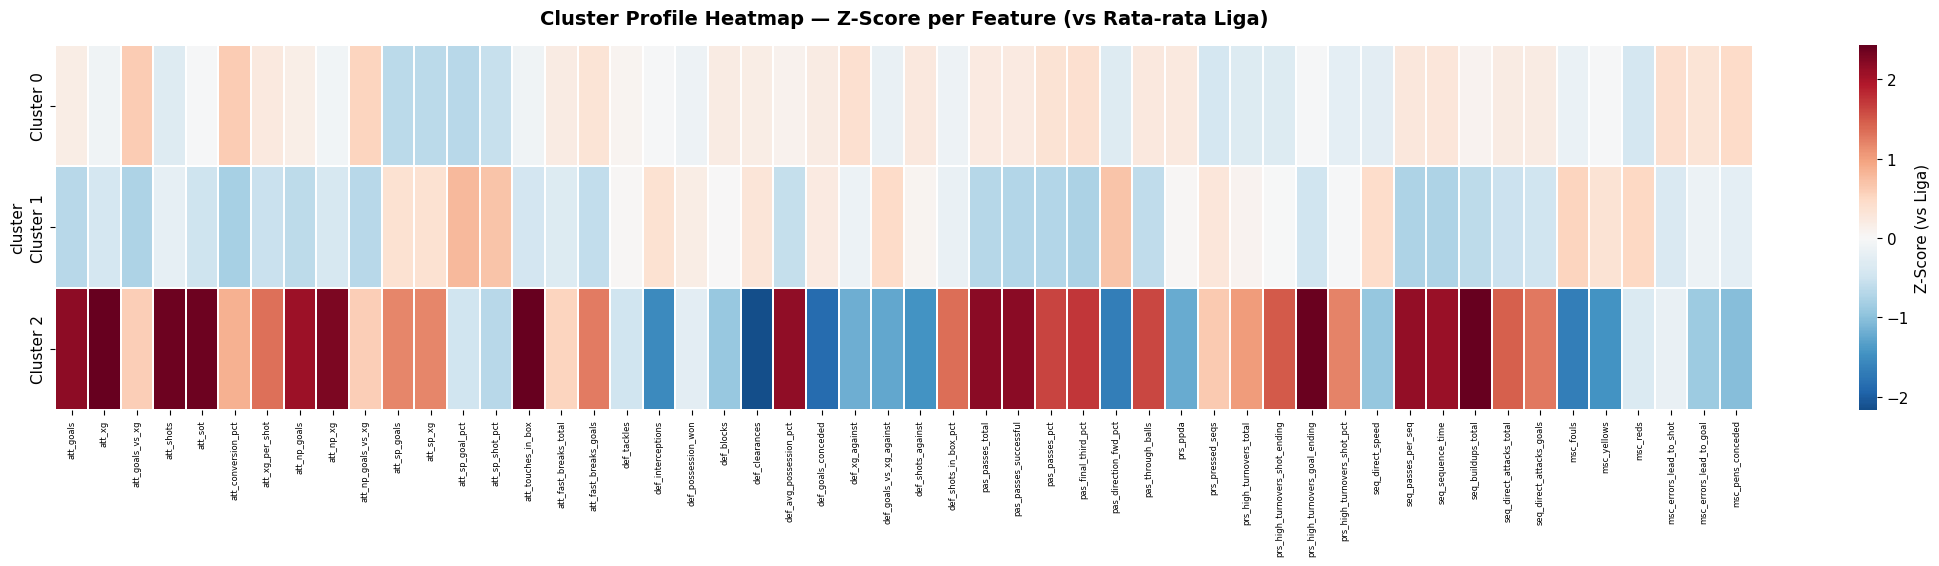

In [160]:
# --- Heatmap Cluster Profile (standardized untuk visualisasi) ---
fig, ax = plt.subplots(figsize=(22, 4 + OPTIMAL_K * 0.6))

sns.heatmap(
    cluster_zscore,
    cmap='RdBu_r', center=0,
    annot=False,
    linewidths=0.3,
    xticklabels=True,
    yticklabels=[f"Cluster {i}" for i in cluster_zscore.index],
    ax=ax,
    cbar_kws={"label": "Z-Score (vs Liga)"},
)
ax.set_title("Cluster Profile Heatmap — Z-Score per Feature (vs Rata-rata Liga)",
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### Interpretasi

Heatmap di atas menunjukkan "signature" masing-masing cluster:
- **Warna merah tua** = feature yang jauh **di atas** rata-rata liga (kekuatan).
- **Warna biru tua** = feature yang jauh **di bawah** rata-rata liga (kelemahan).
- **Warna putih** = mendekati rata-rata liga.

Pola warna yang berbeda antar baris menunjukkan bahwa cluster memiliki karakteristik statistik yang berbeda.

---

## Bagian 13 — Visualisasi Cluster dengan PCA

**PCA digunakan hanya sebagai alat VISUALISASI**, bukan sebagai input K-Means.

K-Means tetap dilatih menggunakan **seluruh 52 feature** setelah scaling. PCA mereduksi dimensi ke 2 komponen agar cluster dapat ditampilkan pada scatter plot.

> PC1 dan PC2 **bukan** cluster. Mereka hanya representasi visual dari variasi data berdimensi tinggi.

In [161]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ev1 = pca.explained_variance_ratio_[0] * 100
ev2 = pca.explained_variance_ratio_[1] * 100

print(f"📐 PCA (untuk visualisasi):")
print(f"   PC1 explained variance: {ev1:.1f}%")
print(f"   PC2 explained variance: {ev2:.1f}%")
print(f"   Total                 : {ev1+ev2:.1f}%")

📐 PCA (untuk visualisasi):
   PC1 explained variance: 42.5%
   PC2 explained variance: 13.9%
   Total                 : 56.4%


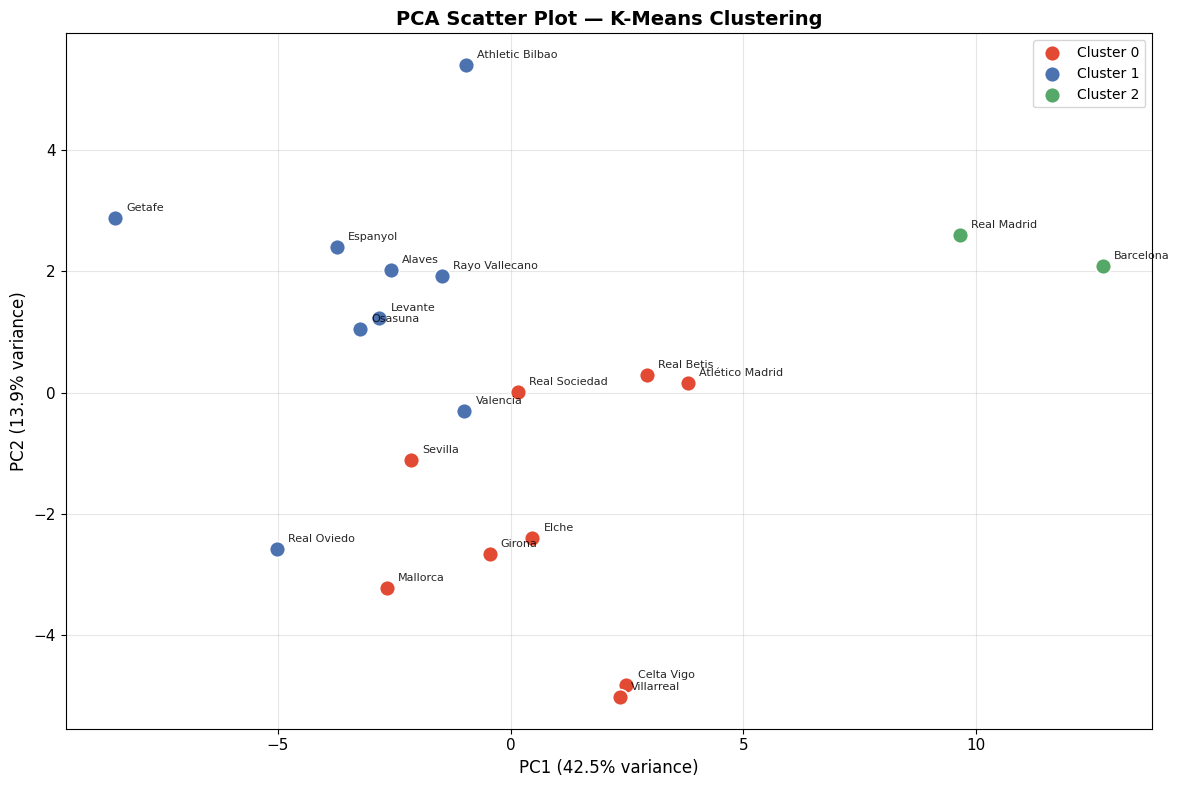

In [162]:
fig, ax = plt.subplots(figsize=(12, 8))

for cid in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == cid
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cid], s=130,
        label=f"Cluster {cid}",
        edgecolors='white', linewidth=1.2, zorder=3,
    )

for i, club in enumerate(clubs):
    ax.annotate(club, (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(8, 5),
                fontsize=8, alpha=0.85)

ax.set_xlabel(f"PC1 ({ev1:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({ev2:.1f}% variance)", fontsize=12)
ax.set_title("PCA Scatter Plot — K-Means Clustering", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretasi

Scatter plot PCA memproyeksikan 52 dimensi ke 2 dimensi. Klub yang berdekatan pada plot memiliki karakteristik statistik yang mirip. Warna menunjukkan cluster assignment dari K-Means. Perhatikan bahwa PCA hanya menangkap sebagian variance total, sehingga separasi cluster pada plot 2D mungkin tidak mencerminkan separasi sepenuhnya di ruang 52 dimensi.

---

## Bagian 14 — Visualisasi Tambahan: Radar Chart

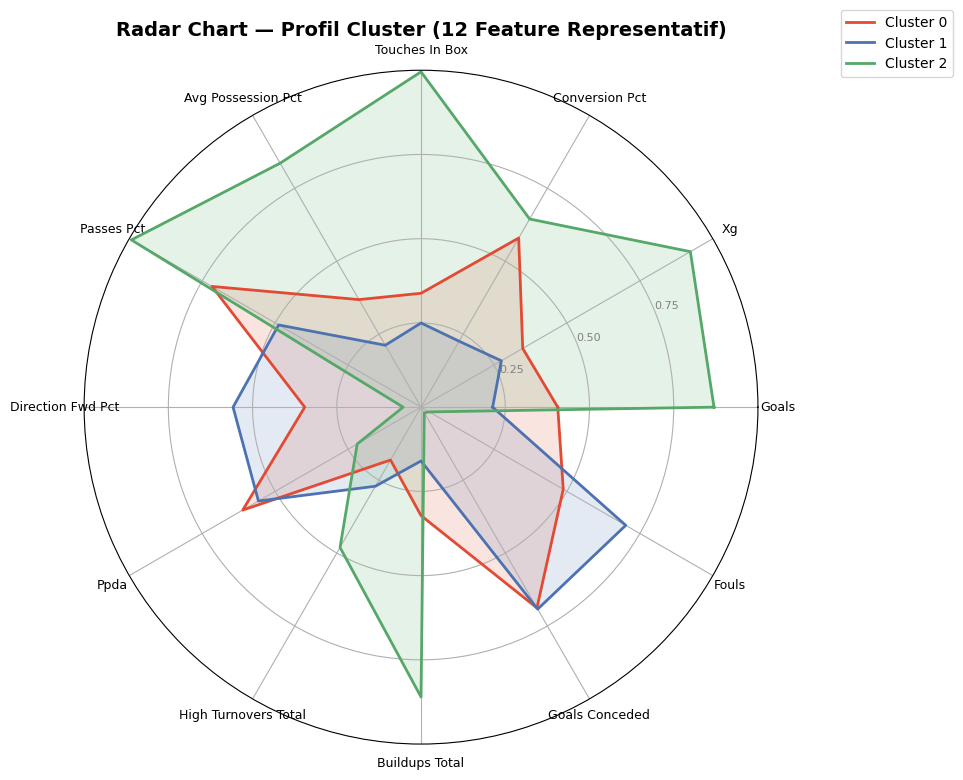

In [163]:
# --- Radar Chart: 12 feature representatif ---
RADAR_FEATURES = [
    "att_goals", "att_xg", "att_conversion_pct", "att_touches_in_box",
    "def_avg_possession_pct", "pas_passes_pct", "pas_direction_fwd_pct",
    "prs_ppda", "prs_high_turnovers_total", "seq_buildups_total",
    "def_goals_conceded", "msc_fouls",
]
RADAR_FEATURES = [f for f in RADAR_FEATURES if f in input_cols]

radar_labels = [f.replace("att_", "").replace("def_", "").replace("pas_", "")
                 .replace("prs_", "").replace("seq_", "").replace("msc_", "")
                 .replace("_", " ").title()
                for f in RADAR_FEATURES]

# Normalisasi 0-1 untuk radar
radar_data = cluster_profile[RADAR_FEATURES].copy()
for col in RADAR_FEATURES:
    mn, mx = df[col].min(), df[col].max()
    radar_data[col] = (radar_data[col] - mn) / (mx - mn) if mx != mn else 0.5

num_vars = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cid in sorted(radar_data.index):
    values = radar_data.loc[cid].tolist() + [radar_data.loc[cid].iloc[0]]
    ax.fill(angles, values, alpha=0.15, color=cluster_colors[cid])
    ax.plot(angles, values, linewidth=2, color=cluster_colors[cid],
            label=f"Cluster {cid}")

ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75])
ax.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=8, color="gray")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_title("Radar Chart — Profil Cluster (12 Feature Representatif)",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

---

## Bagian 15 — Daftar Klub per Cluster

In [164]:
print("📋 Daftar Klub per Cluster")
print("=" * 60)

for cid in sorted(cluster_results["cluster"].unique()):
    clubs_in = cluster_results[cluster_results["cluster"] == cid]["club"].tolist()
    zs = cluster_zscore.loc[cid]
    top_3 = zs.nlargest(3)
    bot_3 = zs.nsmallest(3)

    top_str = ", ".join([f"{f.replace('_', ' ')} ({v:+.1f}σ)" for f, v in top_3.items()])
    bot_str = ", ".join([f"{f.replace('_', ' ')} ({v:+.1f}σ)" for f, v in bot_3.items()])

    print(f"\nCluster {cid} ({len(clubs_in)} klub):")
    for club in clubs_in:
        print(f"   • {club}")
    print(f"   Karakteristik tinggi  : {top_str}")
    print(f"   Karakteristik rendah  : {bot_str}")

print("\n" + "=" * 60)

📋 Daftar Klub per Cluster

Cluster 0 (9 klub):
   • Atlético Madrid
   • Celta Vigo
   • Elche
   • Girona
   • Mallorca
   • Real Betis
   • Real Sociedad
   • Sevilla
   • Villarreal
   Karakteristik tinggi  : att goals vs xg (+0.6σ), att conversion pct (+0.6σ), att np goals vs xg (+0.5σ)
   Karakteristik rendah  : att sp goal pct (-0.7σ), att sp xg (-0.6σ), att sp goals (-0.6σ)

Cluster 1 (9 klub):
   • Alaves
   • Athletic Bilbao
   • Espanyol
   • Getafe
   • Levante
   • Osasuna
   • Rayo Vallecano
   • Real Oviedo
   • Valencia
   Karakteristik tinggi  : att sp goal pct (+0.8σ), att sp shot pct (+0.7σ), pas direction fwd pct (+0.7σ)
   Karakteristik rendah  : att conversion pct (-0.8σ), pas final third pct (-0.8σ), seq passes per seq (-0.7σ)

Cluster 2 (2 klub):
   • Barcelona
   • Real Madrid
   Karakteristik tinggi  : att touches in box (+2.4σ), seq buildups total (+2.4σ), att xg (+2.4σ)
   Karakteristik rendah  : def clearances (-2.2σ), def goals conceded (-1.9σ), pas directi

---

## Bagian 16 — Klub yang Berada di Batas Cluster

K-Means memberikan *hard assignment* — setiap klub hanya memiliki satu label cluster. Dengan menghitung **jarak ke centroid**, kita dapat mengidentifikasi:
- Klub yang **dekat** dengan centroid → representatif kuat dari cluster.
- Klub yang **jauh** dari centroid → mungkin memiliki karakteristik yang lebih unik dalam cluster.

In [165]:
# --- Hitung distance ke centroid ---
distances = np.linalg.norm(
    X_scaled - centroids_scaled[cluster_labels], axis=1
)

df_distance = pd.DataFrame({
    "club": clubs.values,
    "cluster": cluster_labels,
    "distance_to_centroid": distances,
}).sort_values(["cluster", "distance_to_centroid"])

print("📊 Distance to Centroid per Klub:\n")
df_distance.round(4).reset_index(drop=True)

📊 Distance to Centroid per Klub:



,club,cluster,distance_to_centroid
0,Real Sociedad,0,4.44
1,Elche,0,4.57
2,Girona,0,5.24
3,Atlético Madrid,0,5.26
4,Mallorca,0,5.30
5,Celta Vigo,0,5.54
6,Sevilla,0,5.79
7,Real Betis,0,6.09
8,Villarreal,0,7.32
9,Alaves,1,3.49


In [166]:
# --- Klub terdekat dan terjauh per cluster ---
print("🔍 Klub Terdekat dan Terjauh dari Centroid:\n")
for cid in sorted(df_distance["cluster"].unique()):
    subset = df_distance[df_distance["cluster"] == cid]
    closest = subset.iloc[0]
    farthest = subset.iloc[-1]

    print(f"   Cluster {cid}:")
    print(f"      Terdekat : {closest['club']:<20s} (d = {closest['distance_to_centroid']:.4f})")
    print(f"      Terjauh  : {farthest['club']:<20s} (d = {farthest['distance_to_centroid']:.4f})")
    print()

🔍 Klub Terdekat dan Terjauh dari Centroid:

   Cluster 0:
      Terdekat : Real Sociedad        (d = 4.4386)
      Terjauh  : Villarreal           (d = 7.3172)

   Cluster 1:
      Terdekat : Alaves               (d = 3.4883)
      Terjauh  : Getafe               (d = 8.0995)

   Cluster 2:
      Terdekat : Barcelona            (d = 3.9325)
      Terjauh  : Real Madrid          (d = 3.9325)



### Interpretasi

Klub yang dekat dengan centroid merupakan "representan" paling tipikal dari cluster tersebut. Klub yang jauh dari centroid memiliki karakteristik yang lebih unik — bukan berarti anomali, tetapi lebih "berbeda" dibanding anggota cluster lainnya.

---

## Bagian 17 — Evaluasi Hasil Clustering

Karena clustering adalah **unsupervised learning**, tidak ada *accuracy* seperti classification. Evaluasi dilakukan berdasarkan:

| Metrik | Arti | Nilai Ideal |
|--------|------|------------|
| **Inertia** | Total jarak kuadrat observation ke centroid | Semakin kecil semakin compact |
| **Silhouette Score** | Kecocokan observation dalam cluster vs cluster lain | Mendekati +1 |
| **Davies-Bouldin Index** | Rasio dispersi intra-cluster vs jarak antar centroid | Semakin kecil semakin baik |

In [167]:
sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)
inertia = kmeans.inertia_

print("📊 Metrik Evaluasi Final:")
print(f"   Inertia             : {inertia:.2f}")
print(f"   Silhouette Score    : {sil:.4f}")
print(f"   Davies-Bouldin Index: {dbi:.4f}")
print(f"\n   K                   : {OPTIMAL_K}")
print(f"   Observations        : {X_scaled.shape[0]}")
print(f"   Features            : {X_scaled.shape[1]}")

📊 Metrik Evaluasi Final:
   Inertia             : 595.63
   Silhouette Score    : 0.1504
   Davies-Bouldin Index: 1.5546

   K                   : 3
   Observations        : 20
   Features            : 52


### Interpretasi

Evaluasi menunjukkan kualitas clustering berdasarkan **compactness** (seberapa rapat anggota cluster), **separation** (seberapa jauh antar cluster), dan **interpretability** (apakah cluster masuk akal secara kontekstual).

---

## Bagian 18 — Interpretasi Sepakbola

Berdasarkan profil cluster yang telah dianalisis, berikut interpretasi karakteristik statistik setiap cluster dalam konteks sepakbola.

In [168]:
print("⚽ Interpretasi Sepakbola — Karakteristik Cluster")
print("=" * 80)

for cid in sorted(cluster_zscore.index):
    clubs_in = cluster_results[cluster_results["cluster"] == cid]["club"].tolist()
    zs = cluster_zscore.loc[cid]

    # Identifikasi pola berdasarkan z-score
    top_5 = zs.nlargest(5)
    bot_5 = zs.nsmallest(5)

    print(f"\n── Cluster {cid} ({len(clubs_in)} klub) ──")
    print(f"   Klub: {', '.join(clubs_in)}")
    print(f"\n   Feature yang MENONJOL (di atas rata-rata liga):")
    for feat, z in top_5.items():
        label = feat.replace("_", " ")
        print(f"      • {label:<40s}  ({z:+.2f}σ)")

    print(f"\n   Feature yang RENDAH (di bawah rata-rata liga):")
    for feat, z in bot_5.items():
        label = feat.replace("_", " ")
        print(f"      • {label:<40s}  ({z:+.2f}σ)")

    # Interpretasi hati-hati
    print(f"\n   💡 Kemungkinan interpretasi:")
    # Cek pola possession
    poss_z = zs.get("def_avg_possession_pct", 0)
    pass_z = zs.get("pas_passes_pct", 0)
    build_z = zs.get("seq_buildups_total", 0)
    goals_z = zs.get("att_goals", 0)
    ppda_z = zs.get("prs_ppda", 0)
    fouls_z = zs.get("msc_fouls", 0)
    conceded_z = zs.get("def_goals_conceded", 0)

    traits = []
    if poss_z > 0.5 and pass_z > 0.3:
        traits.append("cenderung possession-oriented")
    if build_z > 0.5:
        traits.append("kecenderungan build-up play")
    if goals_z > 0.5:
        traits.append("produktivitas serangan tinggi")
    if ppda_z < -0.3:  # PPDA rendah = pressing tinggi
        traits.append("cenderung high pressing")
    if ppda_z > 0.5:
        traits.append("cenderung low block / deep defending")
    if conceded_z > 0.5:
        traits.append("relatif rentan dalam pertahanan")
    if conceded_z < -0.5:
        traits.append("pertahanan relatif solid")
    if fouls_z > 0.5:
        traits.append("permainan cenderung fisik")
    if not traits:
        traits.append("karakteristik mendekati rata-rata liga")

    for t in traits:
        print(f"      → Secara statistik, cluster ini {t}.")

print("\n" + "=" * 80)
print("\n⚠️  Interpretasi di atas bersifat deskriptif berdasarkan statistik.")
print("   Kemiripan karakteristik statistik tidak berarti gaya bermain identik.")

⚽ Interpretasi Sepakbola — Karakteristik Cluster

── Cluster 0 (9 klub) ──
   Klub: Atlético Madrid, Celta Vigo, Elche, Girona, Mallorca, Real Betis, Real Sociedad, Sevilla, Villarreal

   Feature yang MENONJOL (di atas rata-rata liga):
      • att goals vs xg                           (+0.62σ)
      • att conversion pct                        (+0.61σ)
      • att np goals vs xg                        (+0.55σ)
      • msc pens conceded                         (+0.46σ)
      • msc errors lead to shot                   (+0.42σ)

   Feature yang RENDAH (di bawah rata-rata liga):
      • att sp goal pct                           (-0.69σ)
      • att sp xg                                 (-0.65σ)
      • att sp goals                              (-0.64σ)
      • att sp shot pct                           (-0.56σ)
      • prs pressed seqs                          (-0.43σ)

   💡 Kemungkinan interpretasi:
      → Secara statistik, cluster ini karakteristik mendekati rata-rata liga.

── Cluster 

---

## Bagian 19 — Hasil Akhir

In [169]:
# --- DataFrame final ---
kmeans_results = pd.DataFrame({
    "club": clubs.values,
    "cluster": cluster_labels,
    "distance_to_centroid": distances,
})
kmeans_results = kmeans_results.sort_values("club").reset_index(drop=True)

print("📋 Hasil Final K-Means:\n")
kmeans_results

📋 Hasil Final K-Means:



,club,cluster,distance_to_centroid
0,Alaves,1,3.49
1,Athletic Bilbao,1,7.82
2,Atlético Madrid,0,5.26
3,Barcelona,2,3.93
4,Celta Vigo,0,5.54
5,Elche,0,4.57
6,Espanyol,1,3.89
7,Getafe,1,8.10
8,Girona,0,5.24
9,Levante,1,4.85


In [170]:
# --- Simpan hasil ---
output_dir = PROJECT_ROOT / "data" / "ml_ready"
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Cluster assignment
path_results = output_dir / "teams_kmeans_results.csv"
kmeans_results.to_csv(path_results, index=False)
print(f"✅ Disimpan: {path_results.name} ({kmeans_results.shape})")

# 2. Cluster profile
path_profile = output_dir / "cluster_profile.csv"
cluster_profile.to_csv(path_profile)
print(f"✅ Disimpan: {path_profile.name} ({cluster_profile.shape})")

✅ Disimpan: teams_kmeans_results.csv ((20, 3))
✅ Disimpan: cluster_profile.csv ((3, 52))


---

## Bagian 20 — Kesimpulan Notebook

### End-to-End Summary

```
teams_ml_features.csv (53 kolom, 20 klub)
    → Data Validation (missing, duplicate, infinite, dtype)
        → Feature Selection (52 numerical features)
            → StandardScaler (mean=0, std=1)
                → Pemilihan K (Elbow + Silhouette, K=2..8)
                    → K-Means (K optimal, random_state=42)
                        → Cluster Assignment
                            → Cluster Profile + Heatmap
                                → PCA Visualization (2D)
                                    → Interpretasi Sepakbola
```

### Ringkasan Hasil

| Item | Nilai |
|------|-------|
| Dataset | `teams_ml_features.csv` |
| Observations | 20 klub |
| Features | 52 (numerik) |
| Scaling | StandardScaler |
| Kandidat K | 2–8 |
| K final | *ditentukan dari analisis* |
| Silhouette Score | *hasil aktual* |
| Inertia | *hasil aktual* |
| Davies-Bouldin | *hasil aktual* |

### Catatan Penting

1. Hasil K-Means menggambarkan **kemiripan karakteristik statistik** klub berdasarkan feature yang digunakan — bukan berarti klub-klub tersebut pasti memiliki gaya bermain yang identik.
2. K-Means memberikan *hard assignment* — setiap klub hanya masuk satu cluster. Untuk analisis yang lebih nuanced (soft clustering), dapat menggunakan GMM pada notebook terpisah.
3. PCA digunakan **hanya untuk visualisasi**, bukan sebagai input model.
4. Interpretasi gaya bermain bersifat **deskriptif** dan **harus didukung oleh data**.

### Output Files
- `data/ml_ready/teams_kmeans_results.csv` — club, cluster, distance_to_centroid
- `data/ml_ready/cluster_profile.csv` — mean feature per cluster